In [ ]:
!git clone https://github.com/Otza02/satellite-img-segmentation.git
%cd satellite-img-segmentation
!pip install -e .

## -- Reiniciar sesion antes de la siguiente linea --

In [ ]:
%cd /content/satellite-img-segmentation
!unzip data/mumbai_processed.zip -d data/processed

In [1]:
from satelliteSegmentation.dataset import load_data, SatelliteData
from satelliteSegmentation.tokenizer import Tokenizer, IDX2COLOR
import torch
from matplotlib import pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import numpy as np
import pandas as pd

from collections import Counter

In [2]:
data = load_data("train", "../data/processed")

100%|██████████| 5184/5184 [00:12<00:00, 417.99it/s]


Dataset cargado:
X shape = torch.Size([5184, 3, 120, 120])
Y shape = torch.Size([5184, 1, 120, 120])


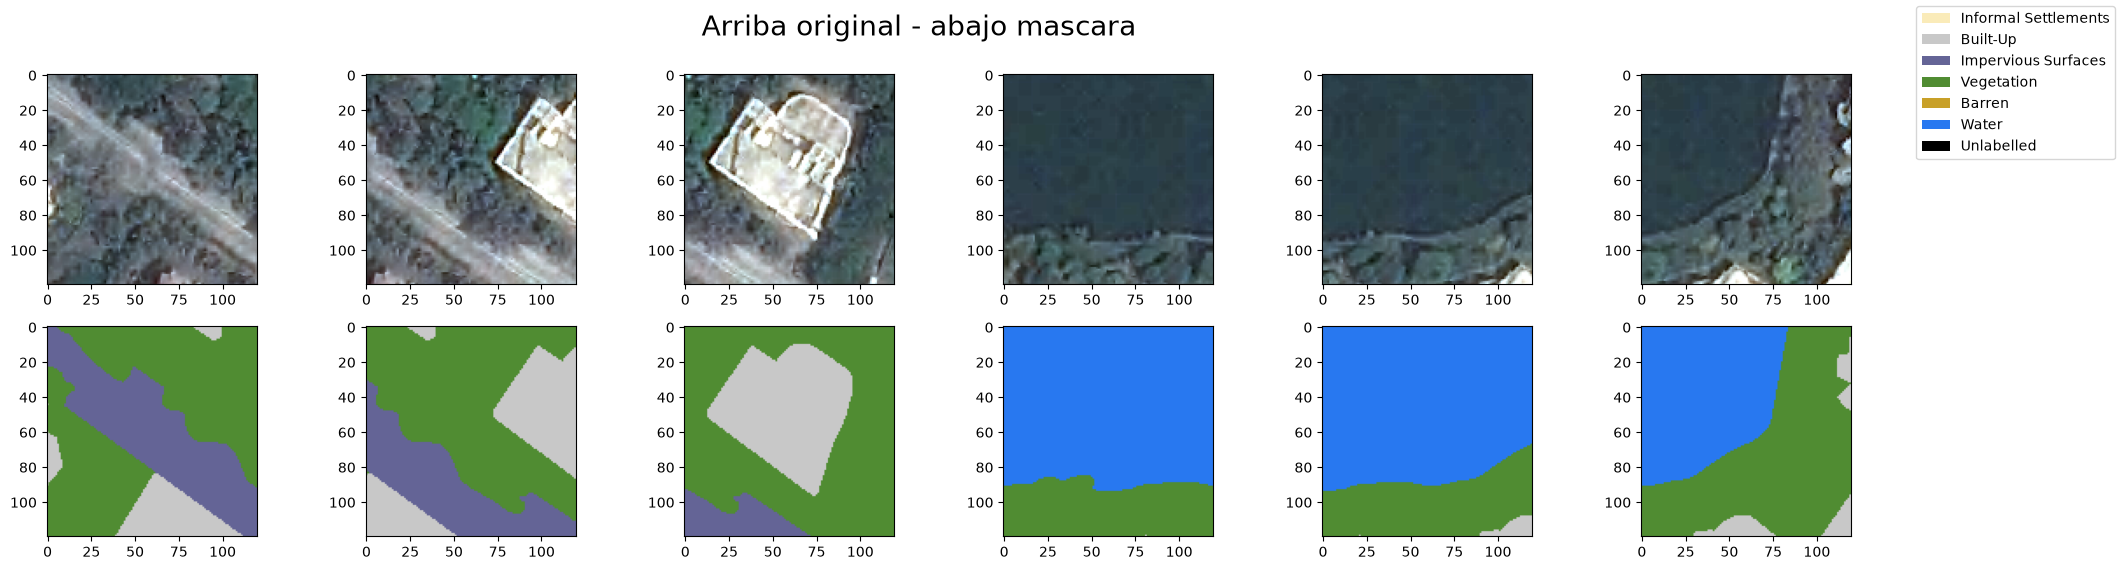

In [6]:
def show_img_mask(data: SatelliteData, n: int = 3, start: int = 0):
    fig, ax = plt.subplots(2, n, figsize=(4 * n, 6))
    for i, img_idx in enumerate(range(start, start + n)):
        # x, y = data[np.random.randint(0, len(data))]
        x, y = data[img_idx]
        ax[0, i].imshow(x.permute(1, 2, 0) / 255)
        # ax[1, i].imshow(y.permute(1, 2, 0) / 255)
        ax[1, i].imshow(Tokenizer.id2color(y).permute(1, 2, 0) / 255)
        
    handles = [
        Patch(
            facecolor=np.array(color) / 255, # type: ignore
            label=Tokenizer.id2name(idx),
        )
        for idx, color in IDX2COLOR.items()
    ]
    fig.legend(
        handles=handles,
        # loc="center right",
        # bbox_to_anchor=(1.15, 0.5)
    )   
    fig.suptitle("Arriba original - abajo mascara", size=20)
    return fig, ax

show_img_mask(data, 6, 300);

tensor([0, 1, 2, 3, 4], dtype=torch.int32)


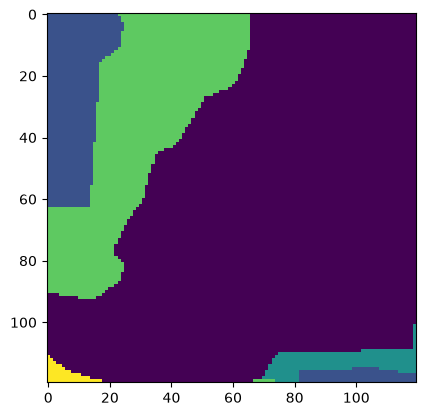

In [56]:
print(torch.unique(data.Y[0]))
plt.imshow(data.Y[0].squeeze(0))

In [96]:
count = Counter()
for y in data.Y:
    count.update([elem.item() for elem in torch.unique(y)])
count

Counter({3: 3374, 4: 3061, 2: 2574, 1: 2335, 0: 1283, 5: 848, 6: 322})

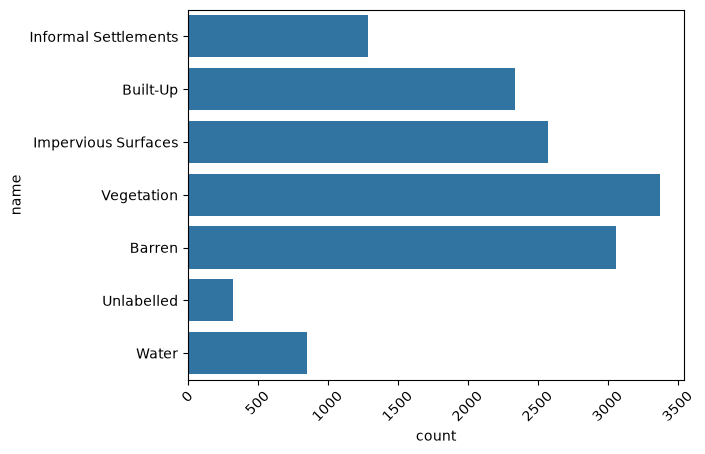

In [97]:
df_counts = pd.DataFrame.from_dict(count, orient='index', columns=["count"]).reset_index()
df_counts = df_counts.rename(columns={"index":"class"})
df_counts["name"] = df_counts["class"].apply(Tokenizer.id2name)

ax = sns.barplot(df_counts, x="count", y="name")
ax.tick_params(axis='x', rotation=45)